# EXLORATORY DATA ANALYSIS

To explore our data, first we need to import these libraries:

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

Now, let's import the clean database using the `parquet` file to load the datatypes we changed previously.

In [2]:
studio_ghibli = pd.read_parquet("../data/Studio Ghibli - Clean.parquet")

studio_ghibli.head()

,Name,Year,Director,Screenplay,Budget,Revenue,Genre 1,Genre 2,Genre 3,Duration
0,When Marnie Was There,2014,Hiromasa Yonebayashi,Joan G. Robinson,1150000000,34949567,Animation,Drama,Thriller,0 days 01:43:00
1,The Tale of The Princess Kaguya,2013,Isao Takahata,Riko Sakaguchi,49300000,24366656,Animation,Drama,Fantasy,0 days 02:17:00
2,The Wind Rises,2013,Hayao Miyazaki,Tatsuo Hori,30000000,117932401,Drama,Animation,Romance,0 days 02:06:00
3,From Up on Poppy Hill,2011,Goro Miyazaki,Hayao Miyazaki,22000000,61037844,Animation,Drama,Romance,0 days 01:31:00
4,The Secret World of Arrietty,2010,Hiromasa Yonebayashi,Mary Norton,23000000,149480483,Fantasy,Animation,Family,0 days 01:34:00


And we can see, the datatypes were successfully loaded. 

In [3]:
studio_ghibli.dtypes

Name                      str
Year                    int16
Director               string
Screenplay             string
Budget                  int64
Revenue                 int64
Genre 1                string
Genre 2                string
Genre 3                string
Duration      timedelta64[us]
dtype: object

Now, let's create the color palette that we will use within the graphs. 

In [4]:
palette = ['#F4E3D3', '#EEBCB1', '#94C5CC', '#F4ADB3', '#ECD89D']
palette_text = ['#ADB7C0', '#A6A0A0']

## Quest 1: Runtime vs. Budget

As defined in my `README` file, for this first quest we are asking ourselves: _"Does the runtime of a Ghibli movie affect the budget?"_. This question leads us to think we need to compare the **Duration** vs. the **Budget**, and this means, we need to compare Numerical vs. Numerical data. For this type of analysis, the best option is to use a **Scatter Plot**.

We will use both `matplotlib` and `seaborn` to show the results of this analysis. 

In [13]:
# Extracting Budget and Duration from the database to compare them
x = studio_ghibli["Duration"].dt.seconds / 60 # This will convert the values we have to minutes. Easier to visualize
y = studio_ghibli["Budget"]


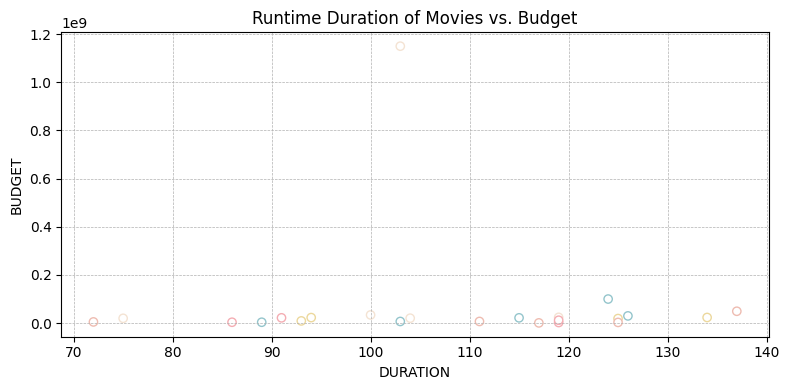

In [28]:
# Scatter Plot
plt.figure(figsize = (8,4)) # 8 x 4 inches plot
plt.scatter(x, y, c = 'w', edgecolor = palette)
plt.title('Runtime Duration of Movies vs. Budget')
plt.xlabel('DURATION')
plt.ylabel('BUDGET')
plt.grid(True, which = 'both', linestyle = '--', linewidth = 0.5)
plt.tight_layout()
plt.show()

With this, we can notice there is an outlier in the `Budget` column, let's analyze it. 

In [ ]:
studio_ghibli["Budget"].sort_values()

21       1000000
8        2500000
16       3000000
12       3700000
13       3700000
6        5000000
17       6900000
11       7000000
19       9200000
18      12000000
9       19000000
20      20000000
10      20500000
3       22000000
7       22000000
4       23000000
14      23500000
15      24000000
2       30000000
5       34000000
1       49300000
22     100000000
0     1150000000
Name: Budget, dtype: int64

We can see there are one extremely large value (in billions!). Before continuing with this analysis, I will check to which movie this value belong and see if it is actually correct by looking it up in Google.

In [32]:
studio_ghibli["Name"].iloc[0]

'When Marnie Was There'

From what I found, the movie "When Marnie Was There" had a budget of ¥1.15 billion, aproximately $10.5 million. The value that we have in our database is the yen value, not the dollar one. If we change this value, there will be no outliers anymore. 

In [40]:
studio_ghibli.loc[studio_ghibli["Name"] == "When Marnie Was There", "Budget"] = 10500000
studio_ghibli.head()

,Name,Year,Director,Screenplay,Budget,Revenue,Genre 1,Genre 2,Genre 3,Duration
0,When Marnie Was There,2014,Hiromasa Yonebayashi,Joan G. Robinson,10500000,34949567,Animation,Drama,Thriller,0 days 01:43:00
1,The Tale of The Princess Kaguya,2013,Isao Takahata,Riko Sakaguchi,49300000,24366656,Animation,Drama,Fantasy,0 days 02:17:00
2,The Wind Rises,2013,Hayao Miyazaki,Tatsuo Hori,30000000,117932401,Drama,Animation,Romance,0 days 02:06:00
3,From Up on Poppy Hill,2011,Goro Miyazaki,Hayao Miyazaki,22000000,61037844,Animation,Drama,Romance,0 days 01:31:00
4,The Secret World of Arrietty,2010,Hiromasa Yonebayashi,Mary Norton,23000000,149480483,Fantasy,Animation,Family,0 days 01:34:00


Now that this value is change, let's save it again so we can load the correct one for later use. 

In [42]:
studio_ghibli.to_csv("../data/Studio Ghibli - Clean.csv")
studio_ghibli.to_parquet("../data/Studio Ghibli - Clean.parquet")

And plotting it again, we have that: 

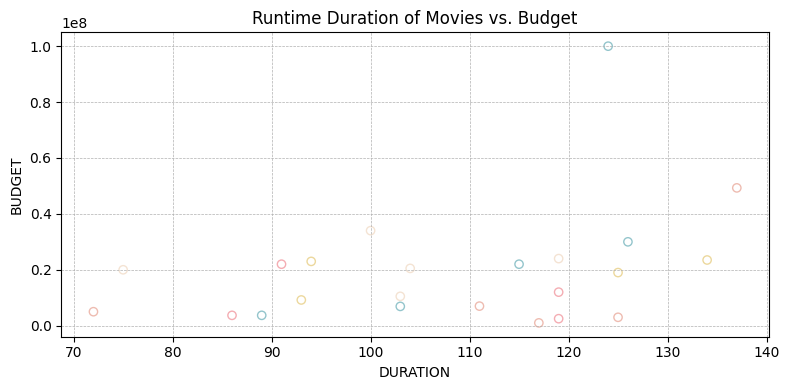

In [44]:
x = studio_ghibli["Duration"].dt.seconds / 60
y = studio_ghibli["Budget"]

# Scatter Plot
plt.figure(figsize = (8,4)) # 8 x 4 inches plot
plt.scatter(x, y, c = 'w', edgecolor = palette)
plt.title('Runtime Duration of Movies vs. Budget')
plt.xlabel('DURATION')
plt.ylabel('BUDGET')
plt.grid(True, which = 'both', linestyle = '--', linewidth = 0.5)
plt.tight_layout()
plt.show()